In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/fares_clean.csv")

df.head()

,collected_at,departure_date,origin,destination,airline,flight_number,departure_time,arrival_time,price,currency,travel_class,stops,source
0,2026-08-23T00:11:56.695231,2026-08-25,DEL,BOM,IndiGo,6E 324,2026-08-25 13:00,2026-08-25 15:10,6425,INR,Economy,0,SerpApi Google Flights
1,2026-08-23T00:11:56.695260,2026-08-25,DEL,BOM,Air India,AI 1785,2026-08-25 12:00,2026-08-25 14:25,6582,INR,Economy,0,SerpApi Google Flights
2,2026-08-23T00:11:56.695268,2026-08-25,DEL,BOM,Akasa Air,QP 1807,2026-08-25 13:40,2026-08-25 15:55,6880,INR,Economy,0,SerpApi Google Flights
3,2026-08-23T00:11:56.699865,2026-08-25,DEL,BOM,IndiGo,6E 324,2026-08-25 13:00,2026-08-25 15:10,6425,INR,Economy,0,SerpApi Google Flights
4,2026-08-23T00:11:56.699887,2026-08-25,DEL,BOM,Air India,AI 1785,2026-08-25 12:00,2026-08-25 14:25,6582,INR,Economy,0,SerpApi Google Flights


In [2]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 36
Number of columns: 13


In [3]:
print(df.columns.tolist())

['collected_at', 'departure_date', 'origin', 'destination', 'airline', 'flight_number', 'departure_time', 'arrival_time', 'price', 'currency', 'travel_class', 'stops', 'source']


In [4]:
df.isnull().sum()

collected_at      0
departure_date    0
origin            0
destination       0
airline           0
flight_number     0
departure_time    0
arrival_time      0
price             0
currency          0
travel_class      0
stops             0
source            0
dtype: int64

In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [6]:
df["price"].describe()

count       36.000000
mean      7713.972222
std       1794.251973
min       4996.000000
25%       6582.000000
50%       7122.500000
75%       8522.000000
max      12419.000000
Name: price, dtype: float64

In [7]:
df[["origin", "destination"]].drop_duplicates()

,origin,destination
0,DEL,BOM
6,DEL,BLR
9,DEL,HYD
12,DEL,CCU
15,BOM,BLR
18,BOM,HYD
21,BOM,DEL
26,BLR,DEL
30,BLR,BOM
33,BLR,HYD


In [8]:
df["airline"].value_counts()

airline
IndiGo               15
Air India             9
Akasa Air             9
Air India Express     2
SpiceJet              1
Name: count, dtype: int64

In [9]:
route_analysis = (
    df.groupby(["origin", "destination"])["price"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        minimum="min",
        maximum="max",
        std="std"
    )
    .reset_index()
)

route_analysis

,origin,destination,count,mean,median,minimum,maximum,std
0,BLR,BOM,3,7425.333333,7172.0,7172,7932,438.786205
1,BLR,DEL,4,11600.250000,12042.5,9897,12419,1167.776627
2,BLR,HYD,3,8042.333333,7449.0,7073,9605,1366.304993
3,BOM,BLR,3,5341.000000,5152.0,4996,5875,468.989339
4,BOM,DEL,5,6685.800000,6722.0,6457,6912,166.913750
5,BOM,HYD,3,6273.333333,6480.0,5645,6695,554.669571
6,DEL,BLR,3,8780.666667,8735.0,8576,9031,230.911960
7,DEL,BOM,6,6629.000000,6582.0,6425,6880,206.713328
8,DEL,CCU,3,8360.333333,8346.0,8231,8504,137.063246
9,DEL,HYD,3,8476.666667,8451.0,8295,8684,195.766017


In [10]:
cheapest_routes = route_analysis.sort_values(
    "median",
    ascending=True
)

cheapest_routes[
    ["origin", "destination", "median", "minimum", "maximum"]
].head(10)

,origin,destination,median,minimum,maximum
3,BOM,BLR,5152.0,4996,5875
5,BOM,HYD,6480.0,5645,6695
7,DEL,BOM,6582.0,6425,6880
4,BOM,DEL,6722.0,6457,6912
0,BLR,BOM,7172.0,7172,7932
2,BLR,HYD,7449.0,7073,9605
8,DEL,CCU,8346.0,8231,8504
9,DEL,HYD,8451.0,8295,8684
6,DEL,BLR,8735.0,8576,9031
1,BLR,DEL,12042.5,9897,12419


In [11]:
expensive_routes = route_analysis.sort_values(
    "median",
    ascending=False
)

expensive_routes[
    ["origin", "destination", "median", "minimum", "maximum"]
].head(10)

,origin,destination,median,minimum,maximum
1,BLR,DEL,12042.5,9897,12419
6,DEL,BLR,8735.0,8576,9031
9,DEL,HYD,8451.0,8295,8684
8,DEL,CCU,8346.0,8231,8504
2,BLR,HYD,7449.0,7073,9605
0,BLR,BOM,7172.0,7172,7932
4,BOM,DEL,6722.0,6457,6912
7,DEL,BOM,6582.0,6425,6880
5,BOM,HYD,6480.0,5645,6695
3,BOM,BLR,5152.0,4996,5875


In [12]:
airline_analysis = (
    df.groupby("airline")["price"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        minimum="min",
        maximum="max",
        std="std"
    )
    .reset_index()
)

airline_analysis.sort_values("median")

,airline,count,mean,median,minimum,maximum,std
0,Air India,9,7710.666667,6614.0,5152,12296,2093.555051
4,SpiceJet,1,6722.000000,6722.0,6722,6722,NaN
1,Air India Express,2,6898.500000,6898.5,6724,7073,246.780267
3,IndiGo,15,7662.933333,7172.0,4996,11789,1785.965064
2,Akasa Air,9,8093.777778,7932.0,5875,12419,1911.981418


In [13]:
route_analysis.to_csv(
    "../data/processed/route_analysis.csv",
    index=False
)

airline_analysis.to_csv(
    "../data/processed/airline_analysis.csv",
    index=False
)

print("Analysis files saved successfully.")

Analysis files saved successfully.


In [14]:
import pandas as pd

df_features = pd.read_csv(
    "../data/processed/fares_features.csv"
)

df_features.head()

,collected_at,departure_date,origin,destination,airline,flight_number,departure_time,arrival_time,price,currency,...,collection_date,collection_time,flight_date,route,days_to_departure,departure_day,departure_hour,arrival_hour,is_weekend,log_price
0,2026-08-23 00:11:56.800702,2026-08-25,BLR,BOM,IndiGo,6E 5218,2026-08-25 13:00:00,2026-08-25 14:50:00,7172,INR,...,2026-08-23,00:11:56.800702,2026-08-25,BLR-BOM,2,Tuesday,13,14,False,8.878079
1,2026-08-23 00:11:56.800721,2026-08-25,BLR,BOM,IndiGo,6E 5351,2026-08-25 14:20:00,2026-08-25 16:05:00,7172,INR,...,2026-08-23,00:11:56.800721,2026-08-25,BLR-BOM,2,Tuesday,14,16,False,8.878079
2,2026-08-23 00:11:56.800726,2026-08-25,BLR,BOM,Akasa Air,QP 1132,2026-08-25 15:20:00,2026-08-25 17:15:00,7932,INR,...,2026-08-23,00:11:56.800726,2026-08-25,BLR-BOM,2,Tuesday,15,17,False,8.978787
3,2026-08-23 00:11:56.780948,2026-08-25,BLR,DEL,IndiGo,6E 6653,2026-08-25 12:35:00,2026-08-25 18:00:00,9897,INR,...,2026-08-23,00:11:56.780948,2026-08-25,BLR-DEL,2,Tuesday,12,18,False,9.200088
4,2026-08-23 00:11:56.780962,2026-08-25,BLR,DEL,IndiGo,6E 840,2026-08-25 13:55:00,2026-08-25 16:45:00,11789,INR,...,2026-08-23,00:11:56.780962,2026-08-25,BLR-DEL,2,Tuesday,13,16,False,9.375007


In [15]:
df_features[
    [
        "collection_date",
        "flight_date",
        "route",
        "airline",
        "price",
        "days_to_departure"
    ]
].head(20)

,collection_date,flight_date,route,airline,price,days_to_departure
0,2026-08-23,2026-08-25,BLR-BOM,IndiGo,7172,2
1,2026-08-23,2026-08-25,BLR-BOM,IndiGo,7172,2
2,2026-08-23,2026-08-25,BLR-BOM,Akasa Air,7932,2
3,2026-08-23,2026-08-25,BLR-DEL,IndiGo,9897,2
4,2026-08-23,2026-08-25,BLR-DEL,IndiGo,11789,2
5,2026-08-23,2026-08-25,BLR-DEL,Air India,12296,2
6,2026-08-23,2026-08-25,BLR-DEL,Akasa Air,12419,2
7,2026-08-23,2026-08-25,BLR-HYD,Air India Express,7073,2
8,2026-08-23,2026-08-25,BLR-HYD,IndiGo,7449,2
9,2026-08-23,2026-08-25,BLR-HYD,IndiGo,9605,2


In [16]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/fares_features.csv"
)

df.head()

,collected_at,departure_date,origin,destination,airline,flight_number,departure_time,arrival_time,price,currency,...,collection_date,collection_time,flight_date,route,days_to_departure,departure_day,departure_hour,arrival_hour,is_weekend,log_price
0,2026-08-23 00:11:56.800702,2026-08-25,BLR,BOM,IndiGo,6E 5218,2026-08-25 13:00:00,2026-08-25 14:50:00,7172,INR,...,2026-08-23,00:11:56.800702,2026-08-25,BLR-BOM,2,Tuesday,13,14,False,8.878079
1,2026-08-23 00:11:56.800721,2026-08-25,BLR,BOM,IndiGo,6E 5351,2026-08-25 14:20:00,2026-08-25 16:05:00,7172,INR,...,2026-08-23,00:11:56.800721,2026-08-25,BLR-BOM,2,Tuesday,14,16,False,8.878079
2,2026-08-23 00:11:56.800726,2026-08-25,BLR,BOM,Akasa Air,QP 1132,2026-08-25 15:20:00,2026-08-25 17:15:00,7932,INR,...,2026-08-23,00:11:56.800726,2026-08-25,BLR-BOM,2,Tuesday,15,17,False,8.978787
3,2026-08-23 00:11:56.780948,2026-08-25,BLR,DEL,IndiGo,6E 6653,2026-08-25 12:35:00,2026-08-25 18:00:00,9897,INR,...,2026-08-23,00:11:56.780948,2026-08-25,BLR-DEL,2,Tuesday,12,18,False,9.200088
4,2026-08-23 00:11:56.780962,2026-08-25,BLR,DEL,IndiGo,6E 840,2026-08-25 13:55:00,2026-08-25 16:45:00,11789,INR,...,2026-08-23,00:11:56.780962,2026-08-25,BLR-DEL,2,Tuesday,13,16,False,9.375007


In [17]:
df["days_to_departure"].describe()

count    36.0
mean      2.0
std       0.0
min       2.0
25%       2.0
50%       2.0
75%       2.0
max       2.0
Name: days_to_departure, dtype: float64

In [18]:
sorted(
    df["days_to_departure"].dropna().unique()
)

[np.int64(2)]

In [19]:
def booking_window(days):

    if days <= 1:
        return "0-1 days"

    elif days <= 3:
        return "2-3 days"

    elif days <= 7:
        return "4-7 days"

    elif days <= 14:
        return "8-14 days"

    elif days <= 30:
        return "15-30 days"

    else:
        return "31+ days"


df["booking_window"] = (
    df["days_to_departure"]
    .apply(booking_window)
)

In [20]:
df[["days_to_departure", "booking_window"]].head(20)

,days_to_departure,booking_window
0,2,2-3 days
1,2,2-3 days
2,2,2-3 days
3,2,2-3 days
4,2,2-3 days
5,2,2-3 days
6,2,2-3 days
7,2,2-3 days
8,2,2-3 days
9,2,2-3 days


In [21]:
booking_analysis = (
    df.groupby("booking_window")["price"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        minimum="min",
        maximum="max"
    )
    .reset_index()
)

booking_analysis

,booking_window,count,mean,median,minimum,maximum
0,2-3 days,36,7713.972222,7122.5,4996,12419


In [22]:
import pandas as pd

obs = pd.read_csv(
    "../data/processed/observations.csv"
)

obs["days_to_departure"].value_counts().sort_index()

days_to_departure
1.0     34
3.0     34
7.0     38
14.0    34
30.0    36
Name: count, dtype: int64

In [23]:
obs[
    [
        "collected_at",
        "departure_date",
        "days_to_departure",
        "route",
        "airline",
        "price"
    ]
].head(20)

,collected_at,departure_date,days_to_departure,route,airline,price
0,2026-08-23T12:00:57.942656,2026-08-25,NaN,DEL-BOM,IndiGo,6425
1,2026-08-23T12:00:57.942656,2026-08-25,NaN,DEL-BOM,Air India,6582
2,2026-08-23T12:00:57.942656,2026-08-25,NaN,DEL-BOM,Air India Express,6610
3,2026-08-23T12:00:57.942656,2026-08-25,NaN,DEL-BOM,Akasa Air,6880
4,2026-08-23T12:00:57.942656,2026-08-25,NaN,DEL-BLR,IndiGo,8576
5,2026-08-23T12:00:57.942656,2026-08-25,NaN,DEL-BLR,Air India,8735
6,2026-08-23T12:00:57.942656,2026-08-25,NaN,DEL-BLR,Akasa Air,9031
7,2026-08-23T12:00:57.942656,2026-08-25,NaN,DEL-HYD,IndiGo,8295
8,2026-08-23T12:00:57.942656,2026-08-25,NaN,DEL-HYD,Air India,8451
9,2026-08-23T12:00:57.942656,2026-08-25,NaN,DEL-HYD,Akasa Air,8684


In [24]:
obs["days_to_departure"].value_counts(dropna=False).sort_index()

days_to_departure
1.0     34
3.0     34
7.0     38
14.0    34
30.0    36
NaN     39
Name: count, dtype: int64

In [25]:
booking_analysis = (
    obs.dropna(subset=["days_to_departure"])
    .groupby("days_to_departure")["price"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        minimum="min",
        maximum="max"
    )
    .reset_index()
)

booking_analysis

,days_to_departure,count,mean,median,minimum,maximum
0,1.0,34,8386.088235,7724.0,5645,15959
1,3.0,34,7658.617647,7409.5,5152,12463
2,7.0,38,7289.342105,6596.0,4323,11777
3,14.0,34,6792.411765,6598.0,4323,11638
4,30.0,36,6640.222222,6519.5,4323,8740


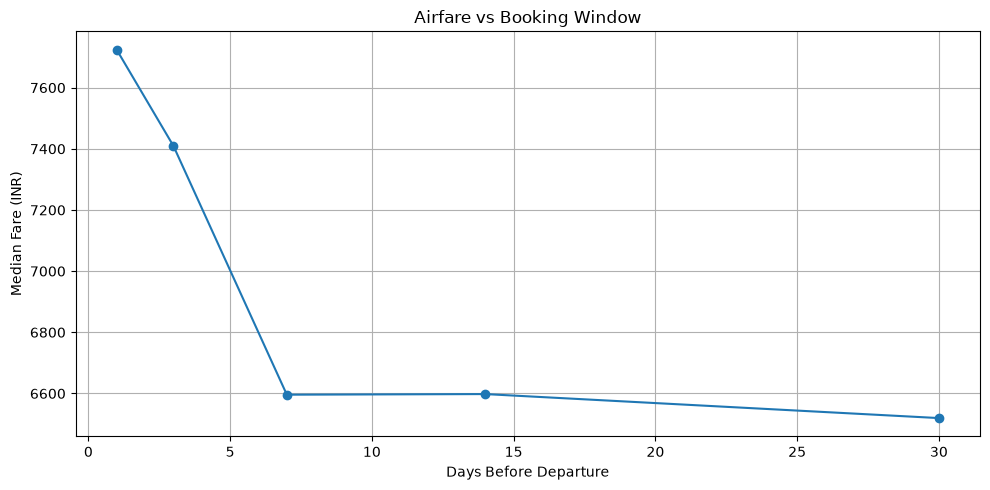

In [26]:
import matplotlib.pyplot as plt

booking_analysis = booking_analysis.sort_values(
    "days_to_departure",
    ascending=False
)

plt.figure(figsize=(10, 5))

plt.plot(
    booking_analysis["days_to_departure"],
    booking_analysis["median"],
    marker="o"
)

plt.xlabel("Days Before Departure")
plt.ylabel("Median Fare (INR)")
plt.title("Airfare vs Booking Window")

plt.grid(True)

plt.tight_layout()

plt.show()

In [27]:
booking_analysis.to_csv(
    "../data/processed/booking_window_analysis.csv",
    index=False
)

print("Booking-window analysis saved successfully.")

Booking-window analysis saved successfully.


In [28]:
import pandas as pd
import matplotlib.pyplot as plt

anomalies = pd.read_csv(
    "../data/processed/anomalies.csv"
)

anomalies.head()

,collected_at,departure_date,origin,destination,route,airline,flight_number,departure_time,arrival_time,price,currency,travel_class,stops,source,days_to_departure,anomaly_prediction,anomaly_score,is_anomaly,anomaly_type
0,2026-08-23T12:28:48.655759,2026-09-06,BOM,BLR,BOM-BLR,Akasa Air,QP 1133,2026-09-06 20:05,2026-09-06 21:45,8671,INR,Economy,0,SerpApi Google Flights,14.0,-1,-0.117541,True,high_price
1,2026-08-23T12:22:22.818116,2026-08-24,BLR,BOM,BLR-BOM,Akasa Air,QP 1528,2026-08-24 10:20,2026-08-24 12:10,15959,INR,Economy,0,SerpApi Google Flights,1.0,-1,-0.088398,True,high_price
2,2026-08-23T12:34:17.472825,2026-09-22,BOM,DEL,BOM-DEL,Akasa Air,QP 1127,2026-09-22 13:00,2026-09-22 15:20,6912,INR,Economy,0,SerpApi Google Flights,30.0,-1,-0.069652,True,high_price
3,2026-08-23T12:27:46.629867,2026-08-30,DEL,BOM,DEL-BOM,Akasa Air,QP 1112,2026-08-30 09:20,2026-08-30 11:45,7243,INR,Economy,0,SerpApi Google Flights,7.0,-1,-0.064619,True,high_price
4,2026-08-23T12:28:48.655759,2026-09-06,DEL,BLR,DEL-BLR,Akasa Air,QP 1308,2026-09-06 20:55,2026-09-06 23:50,11638,INR,Economy,0,SerpApi Google Flights,14.0,-1,-0.061341,True,high_price


In [29]:
route_anomalies = (
    anomalies[anomalies["is_anomaly"] == True]
    .groupby("route")
    .size()
    .sort_values(ascending=False)
)

route_anomalies

route
BLR-BOM    3
BLR-HYD    3
DEL-BOM    3
BOM-DEL    3
BLR-DEL    2
BOM-BLR    2
BOM-HYD    2
DEL-BLR    2
DEL-CCU    2
DEL-HYD    2
dtype: int64

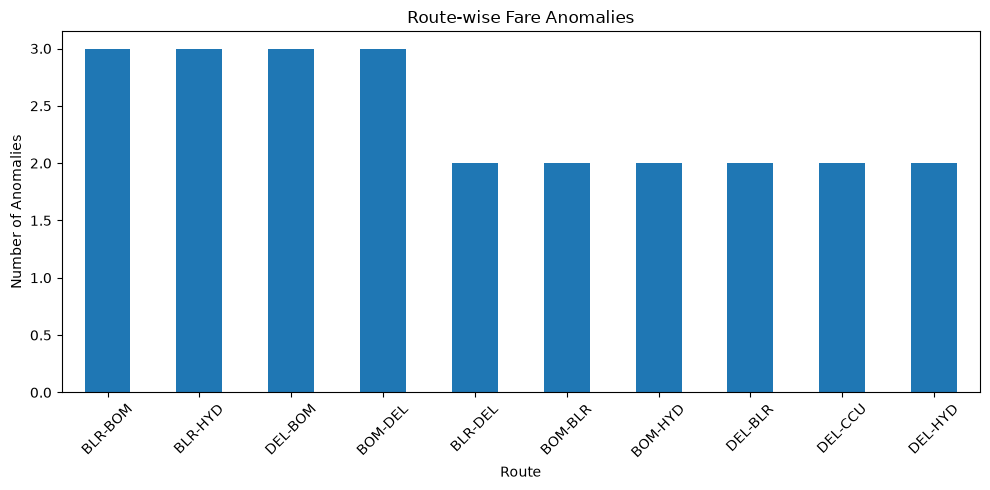

In [30]:
plt.figure(figsize=(10, 5))

route_anomalies.plot(
    kind="bar"
)

plt.xlabel("Route")
plt.ylabel("Number of Anomalies")
plt.title("Route-wise Fare Anomalies")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

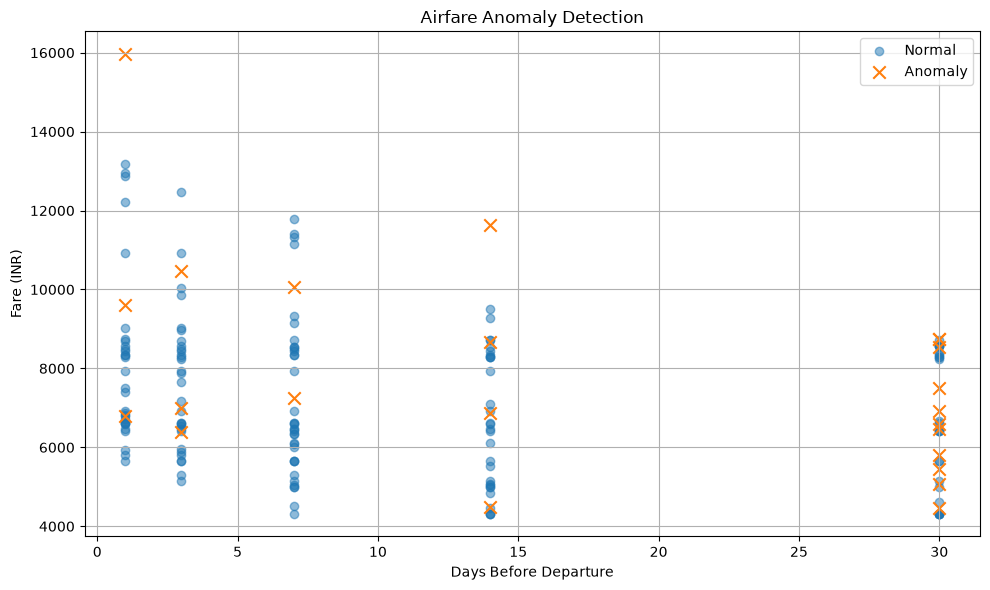

In [31]:
normal = anomalies[
    anomalies["is_anomaly"] == False
]

abnormal = anomalies[
    anomalies["is_anomaly"] == True
]

plt.figure(figsize=(10, 6))

plt.scatter(
    normal["days_to_departure"],
    normal["price"],
    alpha=0.5,
    label="Normal"
)

plt.scatter(
    abnormal["days_to_departure"],
    abnormal["price"],
    marker="x",
    s=80,
    label="Anomaly"
)

plt.xlabel("Days Before Departure")
plt.ylabel("Fare (INR)")
plt.title("Airfare Anomaly Detection")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

In [32]:
dashboard_anomalies = anomalies[
    anomalies["is_anomaly"] == True
][
    [
        "route",
        "airline",
        "price",
        "days_to_departure",
        "anomaly_type",
        "anomaly_score"
    ]
]

dashboard_anomalies.to_csv(
    "../data/processed/dashboard_anomalies.csv",
    index=False
)

print("Dashboard anomaly data saved.")

Dashboard anomaly data saved.


In [33]:
import pandas as pd

index_df = pd.read_csv(
    "../data/processed/airfare_index.csv"
)

index_df.head(20)

,collection_date,route,median_fare,base_fare,route_index,weight,airfare_index
0,2026-08-23,BLR-BOM,7172.0,7172.0,100.0,0.1,100.0
1,2026-08-23,BLR-DEL,12042.5,12042.5,100.0,0.1,100.0
2,2026-08-23,BLR-HYD,7449.0,7449.0,100.0,0.1,100.0
3,2026-08-23,BOM-BLR,5152.0,5152.0,100.0,0.1,100.0
4,2026-08-23,BOM-DEL,6722.0,6722.0,100.0,0.1,100.0
5,2026-08-23,BOM-HYD,6480.0,6480.0,100.0,0.1,100.0
6,2026-08-23,DEL-BLR,8735.0,8735.0,100.0,0.1,100.0
7,2026-08-23,DEL-BOM,6582.0,6582.0,100.0,0.1,100.0
8,2026-08-23,DEL-CCU,8346.0,8346.0,100.0,0.1,100.0
9,2026-08-23,DEL-HYD,8451.0,8451.0,100.0,0.1,100.0


In [34]:
index_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   collection_date  10 non-null     str    
 1   route            10 non-null     str    
 2   median_fare      10 non-null     float64
 3   base_fare        10 non-null     float64
 4   route_index      10 non-null     float64
 5   weight           10 non-null     float64
 6   airfare_index    10 non-null     float64
dtypes: float64(5), str(2)
memory usage: 692.0 bytes


In [35]:
index_df.describe()

,median_fare,base_fare,route_index,weight,airfare_index
count,10.000000,10.000000,10.0,10.0,10.0
mean,7713.150000,7713.150000,100.0,0.1,100.0
std,1868.957405,1868.957405,0.0,0.0,0.0
min,5152.000000,5152.000000,100.0,0.1,100.0
25%,6617.000000,6617.000000,100.0,0.1,100.0
50%,7310.500000,7310.500000,100.0,0.1,100.0
75%,8424.750000,8424.750000,100.0,0.1,100.0
max,12042.500000,12042.500000,100.0,0.1,100.0


In [36]:
index_df = pd.read_csv(
    "../data/processed/airfare_index.csv"
)

print("Rows:", len(index_df))
print("\nCollection dates:")
print(index_df["collection_date"].value_counts().sort_index())

print("\nIndex:")
print(
    index_df[
        [
            "collection_date",
            "route",
            "median_fare",
            "base_fare",
            "route_index",
            "airfare_index"
        ]
    ].head(30)
)

Rows: 10

Collection dates:
collection_date
2026-08-23    10
Name: count, dtype: int64

Index:
  collection_date    route  median_fare  base_fare  route_index  airfare_index
0      2026-08-23  BLR-BOM       7172.0     7172.0        100.0          100.0
1      2026-08-23  BLR-DEL      10237.5    10237.5        100.0          100.0
2      2026-08-23  BLR-HYD       6326.0     6326.0        100.0          100.0
3      2026-08-23  BOM-BLR       5152.0     5152.0        100.0          100.0
4      2026-08-23  BOM-DEL       6614.0     6614.0        100.0          100.0
5      2026-08-23  BOM-HYD       5645.0     5645.0        100.0          100.0
6      2026-08-23  DEL-BLR       8853.0     8853.0        100.0          100.0
7      2026-08-23  DEL-BOM       6582.0     6582.0        100.0          100.0
8      2026-08-23  DEL-CCU       8346.0     8346.0        100.0          100.0
9      2026-08-23  DEL-HYD       8451.0     8451.0        100.0          100.0


In [39]:
print("OBSERVATIONS")
print(obs["departure_date"].value_counts().sort_index())

print("\nCOLLECTION DATES IN OBSERVATIONS")
print(
    pd.to_datetime(obs["collected_at"])
    .dt.date
    .value_counts()
    .sort_index()
)

OBSERVATIONS
departure_date
2026-08-24    34
2026-08-25    39
2026-08-26    34
2026-08-30    38
2026-09-06    34
2026-09-22    36
Name: count, dtype: int64

COLLECTION DATES IN OBSERVATIONS
collected_at
2026-08-23    215
Name: count, dtype: int64


In [41]:
print(clean.columns.tolist())

['collected_at', 'departure_date', 'origin', 'destination', 'airline', 'flight_number', 'departure_time', 'arrival_time', 'price', 'currency', 'travel_class', 'stops', 'source']


In [42]:
print(
    pd.to_datetime(clean["collected_at"])
    .dt.date
    .value_counts()
    .sort_index()
)

collected_at
2026-08-23    251
Name: count, dtype: int64


In [47]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/fares_clean.csv"
)

df["price"] = pd.to_numeric(
    df["price"],
    errors="coerce"
)

# Create route from origin and destination
df["route"] = (
    df["origin"].astype(str)
    + "-"
    + df["destination"].astype(str)
)

df = df.dropna(
    subset=["price", "route", "airline"]
)

df.head()

,collected_at,departure_date,origin,destination,airline,flight_number,departure_time,arrival_time,price,currency,travel_class,stops,source,route
0,2026-08-23T13:34:10.081980,2026-08-25,DEL,BOM,IndiGo,6E 324,2026-08-25 13:00,2026-08-25 15:10,6425,INR,Economy,0,SerpApi Google Flights,DEL-BOM
1,2026-08-23T13:34:10.082005,2026-08-25,DEL,BOM,Air India,AI 1785,2026-08-25 12:00,2026-08-25 14:25,6582,INR,Economy,0,SerpApi Google Flights,DEL-BOM
2,2026-08-23T13:34:10.082011,2026-08-25,DEL,BOM,Akasa Air,QP 1807,2026-08-25 13:40,2026-08-25 15:55,6880,INR,Economy,0,SerpApi Google Flights,DEL-BOM
3,2026-08-23T13:34:10.109761,2026-08-25,DEL,BOM,IndiGo,6E 324,2026-08-25 13:00,2026-08-25 15:10,6425,INR,Economy,0,SerpApi Google Flights,DEL-BOM
4,2026-08-23T13:34:10.109777,2026-08-25,DEL,BOM,Air India,AI 1785,2026-08-25 12:00,2026-08-25 14:25,6582,INR,Economy,0,SerpApi Google Flights,DEL-BOM


In [48]:
route_analysis = (
    df.groupby("route")["price"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        minimum="min",
        maximum="max"
    )
    .reset_index()
)

route_analysis = route_analysis.sort_values(
    "median",
    ascending=True
)

route_analysis

,route,count,mean,median,minimum,maximum
3,BOM-BLR,24,5620.000000,5152.0,4996,8671
5,BOM-HYD,23,5873.434783,5645.0,5524,6695
2,BLR-HYD,27,6378.962963,6326.0,4323,10478
7,DEL-BOM,28,6606.750000,6582.0,6425,7243
4,BOM-DEL,30,6654.266667,6614.0,6390,6912
0,BLR-BOM,25,7337.760000,7172.0,4459,15959
8,DEL-CCU,23,8148.869565,8346.0,6787,8543
9,DEL-HYD,23,8471.478261,8451.0,6990,10061
6,DEL-BLR,24,9364.291667,8853.0,8576,11777
1,BLR-DEL,24,10551.083333,10237.5,8554,13181


In [49]:
route_analysis.to_csv(
    "../data/processed/route_analysis.csv",
    index=False
)

print("Route analysis saved successfully.")

Route analysis saved successfully.


In [50]:
airline_analysis = (
    df.groupby("airline")["price"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        minimum="min",
        maximum="max"
    )
    .reset_index()
)

airline_analysis = airline_analysis.sort_values(
    "median",
    ascending=True
)

airline_analysis

,airline,count,mean,median,minimum,maximum
4,IndiGo,115,7244.730435,6538.0,4323,13181
0,Air India,60,7467.266667,6614.0,4617,12878
5,SpiceJet,8,6626.875000,6695.0,4844,7943
1,Air India Express,19,7303.684211,6724.0,4476,10042
3,Alliance Air,1,7505.000000,7505.0,7505,7505
2,Akasa Air,46,8098.760870,7933.0,5073,15959
6,Star Air,2,8743.000000,8743.0,7886,9600


In [51]:
airline_analysis.to_csv(
    "../data/processed/airline_analysis.csv",
    index=False
)

print("Airline analysis saved successfully.")

Airline analysis saved successfully.


In [52]:
print("CHEAPEST 5 ROUTES")
print(
    route_analysis[
        ["route", "median", "minimum"]
    ].head(5)
)

print("\nMOST EXPENSIVE 5 ROUTES")
print(
    route_analysis[
        ["route", "median", "maximum"]
    ].tail(5)
)

CHEAPEST 5 ROUTES
     route  median  minimum
3  BOM-BLR  5152.0     4996
5  BOM-HYD  5645.0     5524
2  BLR-HYD  6326.0     4323
7  DEL-BOM  6582.0     6425
4  BOM-DEL  6614.0     6390

MOST EXPENSIVE 5 ROUTES
     route   median  maximum
0  BLR-BOM   7172.0    15959
8  DEL-CCU   8346.0     8543
9  DEL-HYD   8451.0    10061
6  DEL-BLR   8853.0    11777
1  BLR-DEL  10237.5    13181


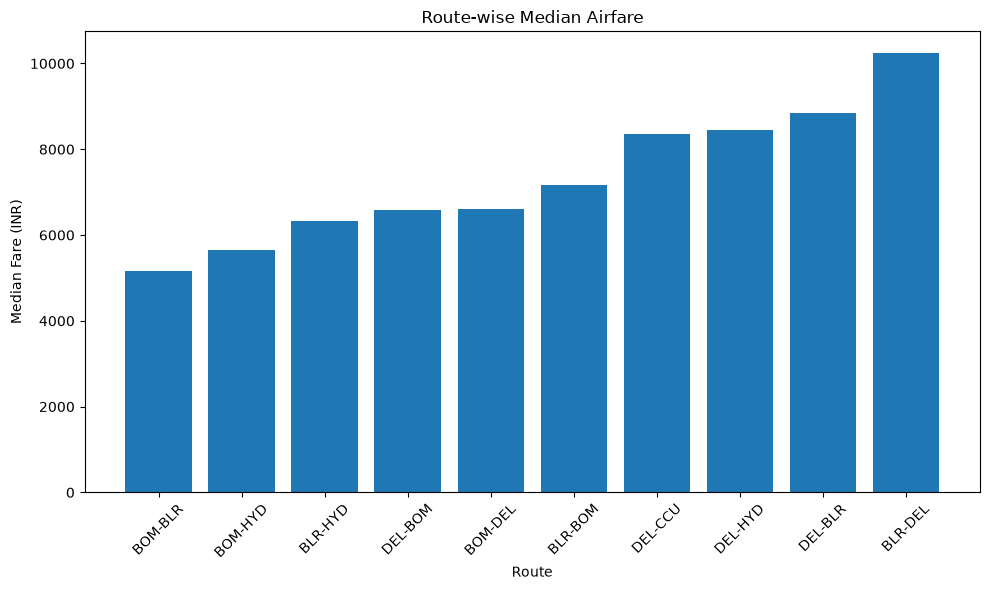

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    route_analysis["route"],
    route_analysis["median"]
)

plt.xlabel("Route")
plt.ylabel("Median Fare (INR)")
plt.title("Route-wise Median Airfare")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

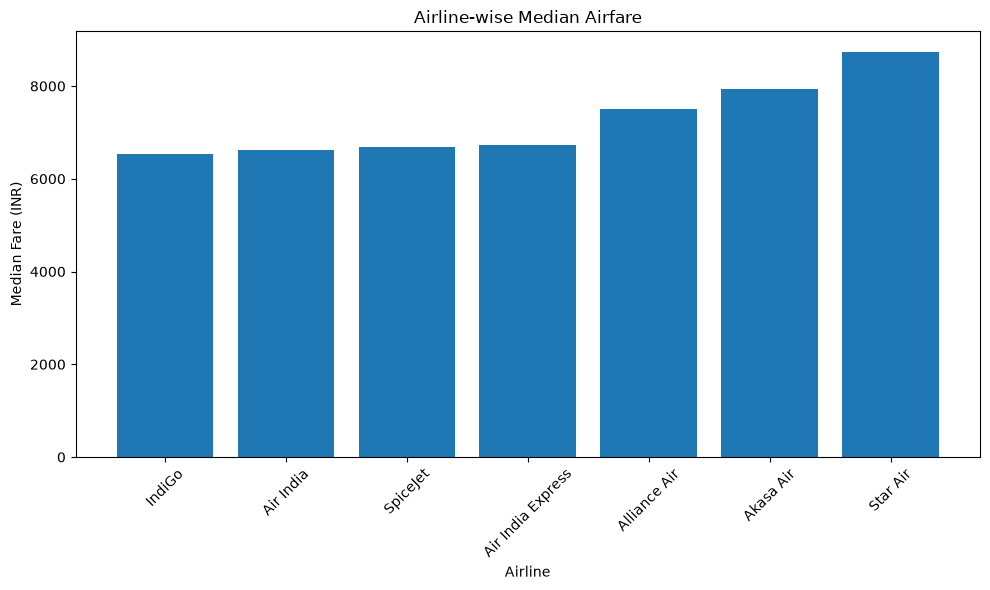

In [54]:
plt.figure(figsize=(10, 6))

plt.bar(
    airline_analysis["airline"],
    airline_analysis["median"]
)

plt.xlabel("Airline")
plt.ylabel("Median Fare (INR)")
plt.title("Airline-wise Median Airfare")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [55]:
route_airline = (
    df.groupby(
        ["route", "airline"]
    )["price"]
    .median()
    .reset_index()
)

route_airline.to_csv(
    "../data/processed/route_airline_analysis.csv",
    index=False
)

route_airline.head(20)

,route,airline,price
0,BLR-BOM,Air India,5037.0
1,BLR-BOM,Akasa Air,7932.0
2,BLR-BOM,IndiGo,7172.0
3,BLR-BOM,SpiceJet,5422.0
4,BLR-DEL,Air India,8710.0
5,BLR-DEL,Air India Express,9970.0
6,BLR-DEL,Akasa Air,12419.0
7,BLR-DEL,IndiGo,10923.0
8,BLR-HYD,Air India Express,7073.0
9,BLR-HYD,Alliance Air,7505.0


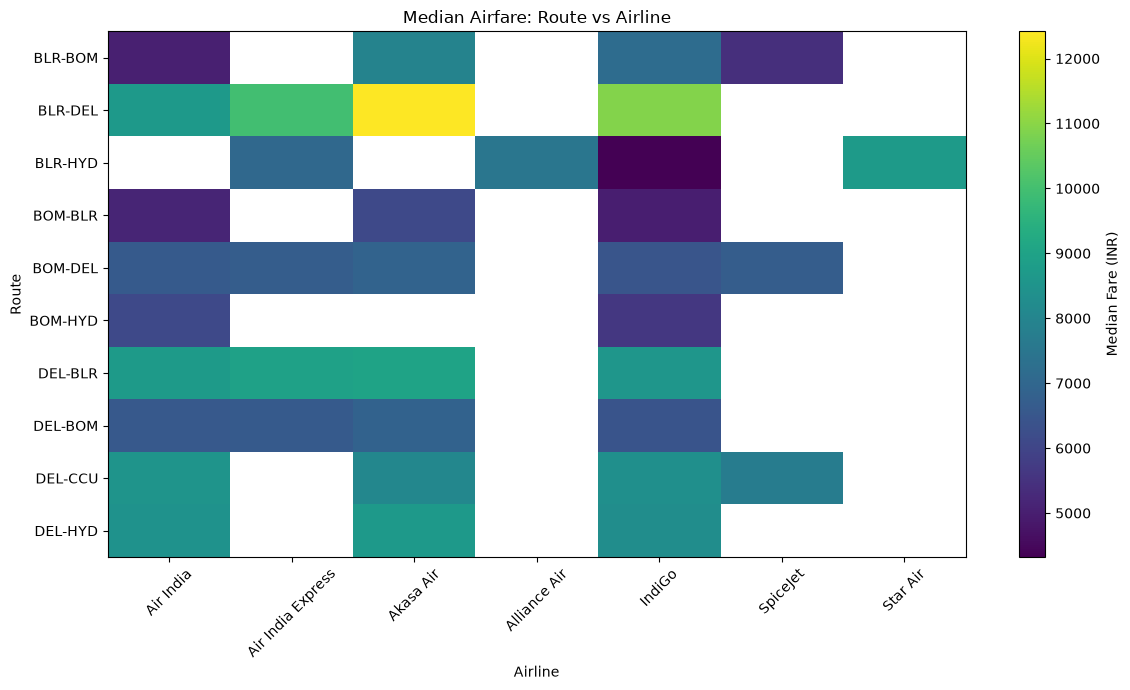

In [56]:
import matplotlib.pyplot as plt

heatmap_data = route_airline.pivot(
    index="route",
    columns="airline",
    values="price"
)

plt.figure(figsize=(12, 7))

plt.imshow(
    heatmap_data,
    aspect="auto"
)

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns,
    rotation=45
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.xlabel("Airline")
plt.ylabel("Route")
plt.title("Median Airfare: Route vs Airline")

plt.colorbar(
    label="Median Fare (INR)"
)

plt.tight_layout()
plt.show()

In [58]:
# Calculate booking window

df["collected_at"] = pd.to_datetime(
    df["collected_at"]
)

df["departure_date"] = pd.to_datetime(
    df["departure_date"]
)

df["days_to_departure"] = (
    df["departure_date"].dt.normalize()
    - df["collected_at"].dt.normalize()
).dt.days

print(
    df[
        [
            "collected_at",
            "departure_date",
            "days_to_departure",
            "price"
        ]
    ].head(10)
)

                collected_at departure_date  days_to_departure  price
0 2026-08-23 13:34:10.081980     2026-08-25                  2   6425
1 2026-08-23 13:34:10.082005     2026-08-25                  2   6582
2 2026-08-23 13:34:10.082011     2026-08-25                  2   6880
3 2026-08-23 13:34:10.109761     2026-08-25                  2   6425
4 2026-08-23 13:34:10.109777     2026-08-25                  2   6582
5 2026-08-23 13:34:10.109779     2026-08-25                  2   6880
6 2026-08-23 13:34:10.135834     2026-08-25                  2   8576
7 2026-08-23 13:34:10.135895     2026-08-25                  2   8735
8 2026-08-23 13:34:10.135906     2026-08-25                  2   9031
9 2026-08-23 13:34:10.169282     2026-08-25                  2   8295


In [59]:
booking_trend = (
    df.dropna(
        subset=["days_to_departure"]
    )
    .groupby("days_to_departure")["price"]
    .median()
    .reset_index()
    .sort_values(
        "days_to_departure",
        ascending=False
    )
)

booking_trend

,days_to_departure,price
5,30,6519.5
4,14,6598.0
3,7,6596.0
2,3,7409.5
1,2,7172.0
0,1,7724.0


In [60]:
booking_trend.to_csv(
    "../data/processed/price_trend.csv",
    index=False
)

print("Price trend saved successfully.")

Price trend saved successfully.


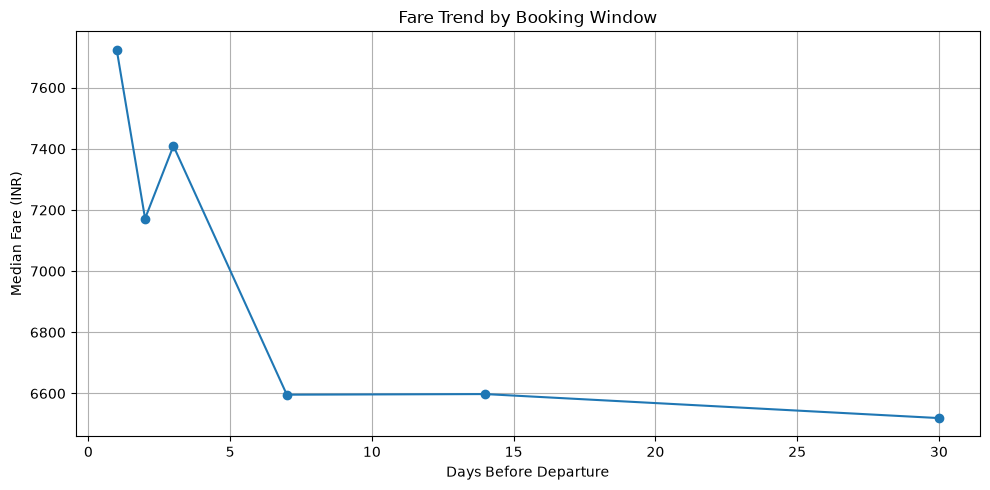

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    booking_trend["days_to_departure"],
    booking_trend["price"],
    marker="o"
)

plt.xlabel("Days Before Departure")
plt.ylabel("Median Fare (INR)")
plt.title("Fare Trend by Booking Window")

plt.grid(True)

plt.tight_layout()
plt.show()

In [62]:
booking_trend.to_csv(
    "../data/processed/price_trend.csv",
    index=False
)

print("Price trend saved successfully.")

Price trend saved successfully.


In [63]:
historical_trend = pd.read_csv(
    "../data/processed/historical_price_trend.csv"
)

historical_trend["date"] = pd.to_datetime(
    historical_trend["date"]
)

historical_trend.head()

,date,count,mean,median,minimum,maximum
0,2022-02-11,1927,21591.867151,15163.0,4452,116562
1,2022-02-12,4031,30180.847680,17996.0,1977,114523
2,2022-02-13,4250,28964.213176,16332.0,3289,123071
3,2022-02-14,5079,25723.780665,13054.0,3124,110936
4,2022-02-15,5395,26669.807044,13054.0,3361,117307


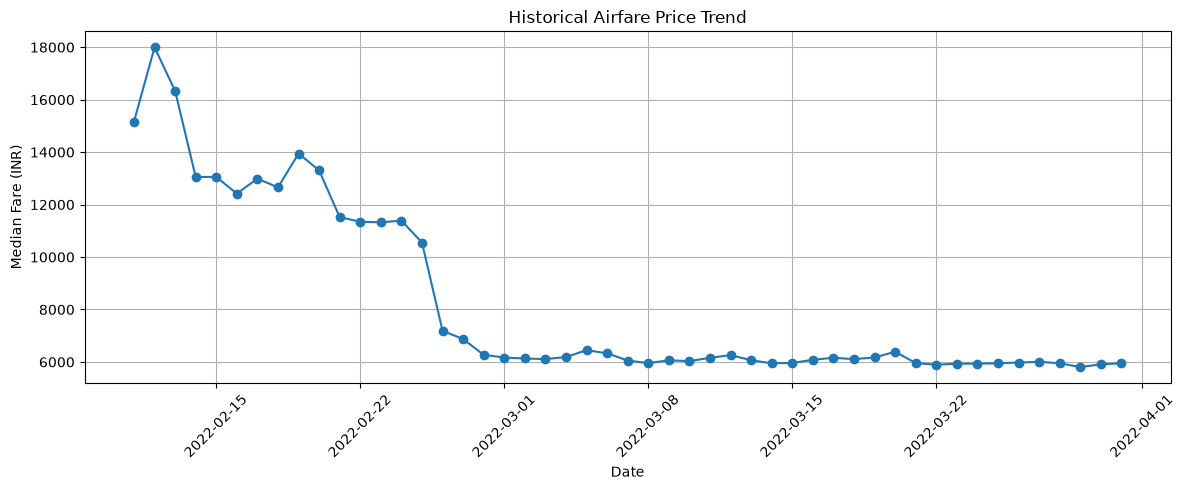

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    historical_trend["date"],
    historical_trend["median"],
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Median Fare (INR)")
plt.title("Historical Airfare Price Trend")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

In [65]:
historical_index = pd.read_csv(
    "../data/processed/historical_airfare_index.csv"
)

historical_index["date"] = pd.to_datetime(
    historical_index["date"]
)

historical_index.head()

,date,airfare_index
0,2022-02-11,100.000000
1,2022-02-12,93.493045
2,2022-02-13,84.195353
3,2022-02-14,74.578410
4,2022-02-15,71.527468


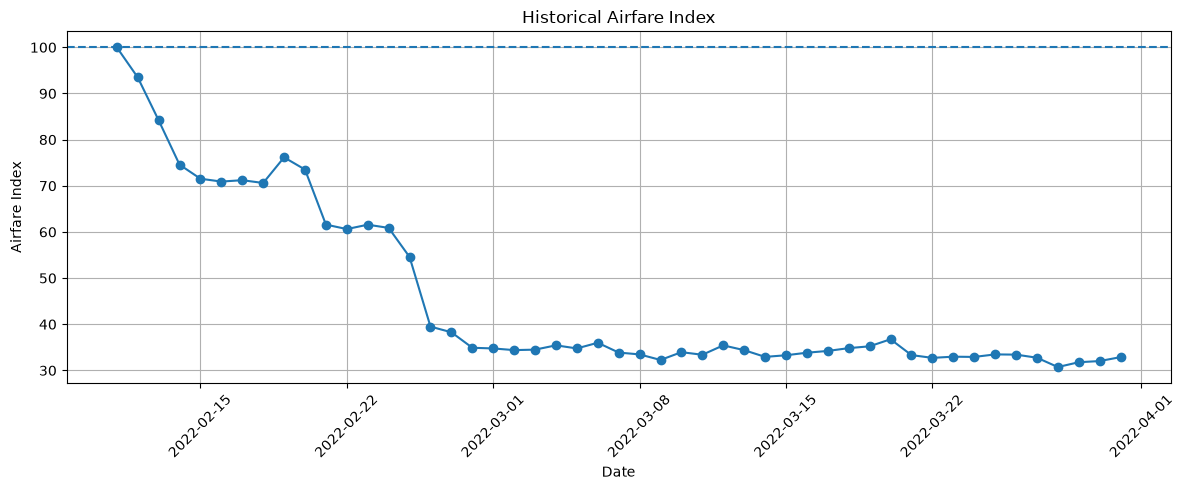

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    historical_index["date"],
    historical_index["airfare_index"],
    marker="o"
)

plt.axhline(
    100,
    linestyle="--"
)

plt.xlabel("Date")
plt.ylabel("Airfare Index")
plt.title("Historical Airfare Index")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

In [68]:
import pandas as pd

forecast = pd.read_csv(
    "../data/processed/airfare_forecast.csv"
)

forecast["date"] = pd.to_datetime(
    forecast["date"]
)

forecast.head()

,date,airfare_index,predicted_index
0,2022-03-23,32.974974,32.916809
1,2022-03-24,32.919714,33.677986
2,2022-03-25,33.467023,34.058471
3,2022-03-26,33.421229,34.453987
4,2022-03-27,32.752515,34.624605


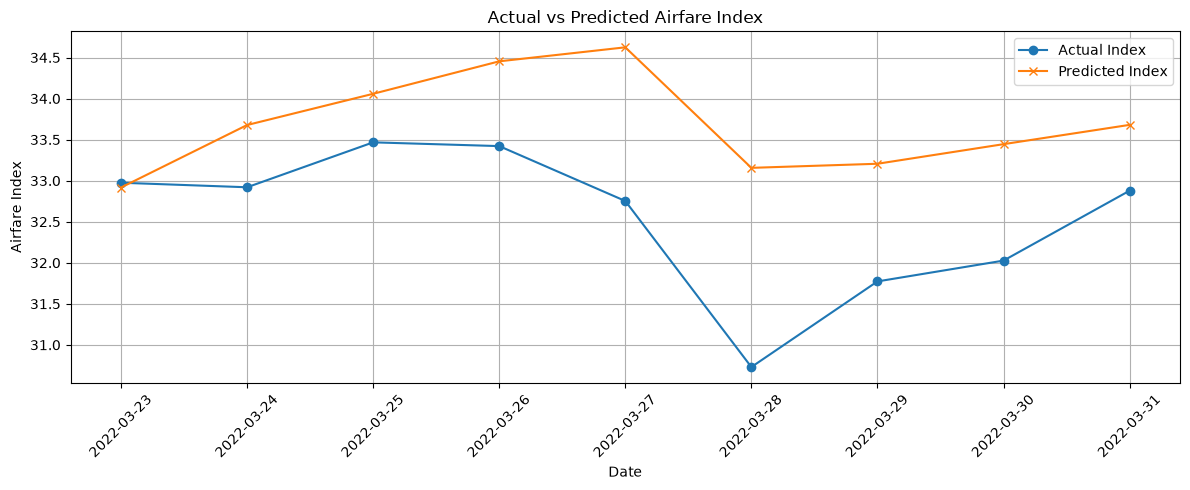

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    forecast["date"],
    forecast["airfare_index"],
    marker="o",
    label="Actual Index"
)

plt.plot(
    forecast["date"],
    forecast["predicted_index"],
    marker="x",
    label="Predicted Index"
)

plt.xlabel("Date")
plt.ylabel("Airfare Index")
plt.title("Actual vs Predicted Airfare Index")

plt.xticks(rotation=45)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [70]:
import os

files_to_check = [
    "../data/processed/fare_clean.csv",
    "../data/processed/fares_clean.csv",
    "../data/processed/fare_features.csv",
    "../data/processed/observations.csv",
    "../data/processed/airfare_index.csv",
    "../data/processed/route_analysis.csv",
    "../data/processed/airline_analysis.csv",
    "../data/processed/route_airline_analysis.csv",
    "../data/processed/price_trend.csv",
    "../data/processed/historical_clean.csv",
    "../data/processed/historical_booking_window.csv",
    "../data/processed/historical_route_analysis.csv",
    "../data/processed/historical_airline_analysis.csv",
    "../data/processed/historical_price_trend.csv",
    "../data/processed/historical_airfare_index.csv",
    "../data/processed/airfare_forecast.csv",
    "../data/processed/forecast_metrics.csv",
]

for file in files_to_check:
    status = "✅ EXISTS" if os.path.exists(file) else "❌ MISSING"
    print(status, file)

❌ MISSING ../data/processed/fare_clean.csv
✅ EXISTS ../data/processed/fares_clean.csv
❌ MISSING ../data/processed/fare_features.csv
✅ EXISTS ../data/processed/observations.csv
✅ EXISTS ../data/processed/airfare_index.csv
✅ EXISTS ../data/processed/route_analysis.csv
✅ EXISTS ../data/processed/airline_analysis.csv
✅ EXISTS ../data/processed/route_airline_analysis.csv
✅ EXISTS ../data/processed/price_trend.csv
✅ EXISTS ../data/processed/historical_clean.csv
✅ EXISTS ../data/processed/historical_booking_window.csv
✅ EXISTS ../data/processed/historical_route_analysis.csv
✅ EXISTS ../data/processed/historical_airline_analysis.csv
✅ EXISTS ../data/processed/historical_price_trend.csv
✅ EXISTS ../data/processed/historical_airfare_index.csv
✅ EXISTS ../data/processed/airfare_forecast.csv
❌ MISSING ../data/processed/forecast_metrics.csv
